In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
data_2022 = pd.read_csv("releves_2022.csv", sep=";", index_col=None)
data_2023 = pd.read_csv("releves_2023.csv", sep=";", index_col=None)
data_2024 = pd.read_csv("releves_2024.csv", sep=";", index_col=None)
data_2025 = pd.read_csv("releves_2025.csv", sep=";", index_col=None)
data_2026 = pd.read_csv("releves_2026.csv", sep=";", index_col=None)

In [3]:
# displaying what one dataset looks like
data_2022.head()

,Data rilevamento,Ora,Id Rete Monitoraggio,Codice Istat Comune,Progr. Punto Comune,Denominazione Stazione,Id Parametro,Descr. Parametro,Id Un. misura,Descr. Un. misura,Valore,Stato
0,01/01/2022,23:59,13,1272,806,Torino - Lingotto,PM10_GBV,PM10 - Basso Volume,23,microgrammi / metro cubo,69.0,V
1,02/01/2022,23:59,13,1272,806,Torino - Lingotto,PM10_GBV,PM10 - Basso Volume,23,microgrammi / metro cubo,55.0,V
2,03/01/2022,23:59,13,1272,806,Torino - Lingotto,PM10_GBV,PM10 - Basso Volume,23,microgrammi / metro cubo,63.0,V
3,04/01/2022,23:59,13,1272,806,Torino - Lingotto,PM10_GBV,PM10 - Basso Volume,23,microgrammi / metro cubo,49.0,V
4,05/01/2022,23:59,13,1272,806,Torino - Lingotto,PM10_GBV,PM10 - Basso Volume,23,microgrammi / metro cubo,35.0,V


In [4]:
# a cleaning of the files is necessary
# the problem is due to a trailing ";" at the end of each line
for i in range(2,7): # go from 2 to 6
    file = f"releves_202{i}.csv"
    with open(file, "r") as f:
        content = f.read()

    content = content.replace(";\n", "\n")

    with open(file, "w") as f:
        f.write(content)

In [5]:
# again
data_2022 = pd.read_csv("releves_2022.csv", sep=";", index_col=None)
data_2023 = pd.read_csv("releves_2023.csv", sep=";", index_col=None)
data_2024 = pd.read_csv("releves_2024.csv", sep=";", index_col=None)
data_2025 = pd.read_csv("releves_2025.csv", sep=";", index_col=None)
data_2026 = pd.read_csv("releves_2026.csv", sep=";", index_col=None)

In [6]:
# checking if everything is correct now
data_2022.head()

,Data rilevamento,Ora,Id Rete Monitoraggio,Codice Istat Comune,Progr. Punto Comune,Denominazione Stazione,Id Parametro,Descr. Parametro,Id Un. misura,Descr. Un. misura,Valore,Stato
0,01/01/2022,23:59,13,1272,806,Torino - Lingotto,PM10_GBV,PM10 - Basso Volume,23,microgrammi / metro cubo,69.0,V
1,02/01/2022,23:59,13,1272,806,Torino - Lingotto,PM10_GBV,PM10 - Basso Volume,23,microgrammi / metro cubo,55.0,V
2,03/01/2022,23:59,13,1272,806,Torino - Lingotto,PM10_GBV,PM10 - Basso Volume,23,microgrammi / metro cubo,63.0,V
3,04/01/2022,23:59,13,1272,806,Torino - Lingotto,PM10_GBV,PM10 - Basso Volume,23,microgrammi / metro cubo,49.0,V
4,05/01/2022,23:59,13,1272,806,Torino - Lingotto,PM10_GBV,PM10 - Basso Volume,23,microgrammi / metro cubo,35.0,V


In [7]:
# first let's combine all of the data frames
years = range(2022, 2027)
dataframes = {}

for year in years:
    dataframes[year] = pd.read_csv(f"releves_{year}.csv", sep=";")

superset = pd.concat(dataframes.values(), ignore_index=True)


In [8]:
superset.head()

,Data rilevamento,Ora,Id Rete Monitoraggio,Codice Istat Comune,Progr. Punto Comune,Denominazione Stazione,Id Parametro,Descr. Parametro,Id Un. misura,Descr. Un. misura,Valore,Stato
0,01/01/2022,23:59,13,1272,806,Torino - Lingotto,PM10_GBV,PM10 - Basso Volume,23,microgrammi / metro cubo,69.0,V
1,02/01/2022,23:59,13,1272,806,Torino - Lingotto,PM10_GBV,PM10 - Basso Volume,23,microgrammi / metro cubo,55.0,V
2,03/01/2022,23:59,13,1272,806,Torino - Lingotto,PM10_GBV,PM10 - Basso Volume,23,microgrammi / metro cubo,63.0,V
3,04/01/2022,23:59,13,1272,806,Torino - Lingotto,PM10_GBV,PM10 - Basso Volume,23,microgrammi / metro cubo,49.0,V
4,05/01/2022,23:59,13,1272,806,Torino - Lingotto,PM10_GBV,PM10 - Basso Volume,23,microgrammi / metro cubo,35.0,V


In [9]:
superset.shape

(3086, 12)

correct shape for all days from 2022 to 23 march 2026

In [10]:
# checking for NaN values
superset.isna().sum()

Data rilevamento            0
Ora                         0
Id Rete Monitoraggio        0
Codice Istat Comune         0
Progr. Punto Comune         0
Denominazione Stazione      0
Id Parametro                0
Descr. Parametro            0
Id Un. misura               0
Descr. Un. misura           0
Valore                    409
Stato                       0
dtype: int64

In [11]:
# we interpolate missing value with the one of the day before
superset["Valore"] = superset["Valore"].ffill() # filling NaN values with the previous real number seen
print(superset["Valore"].isna().sum())

0


In [12]:
# splitting superset to two datasets exclusively of pm10 and pm2.5
# checking indexing of measurements of both types of particles
superset["Id Parametro"].value_counts()

Id Parametro
PM2.5       1461
PM10_GBV    1178
PM10_B       365
PM2.5_B       82
Name: count, dtype: int64

In [13]:
data_pm10 = superset.loc[(superset["Id Parametro"] == "PM10_GBV") | (superset["Id Parametro"] == "PM10_B")].copy()
data_pm10= data_pm10.reset_index(drop=True)

# renaming columns from italian to english for convenience
data_pm10 = data_pm10.rename(columns={
    "Data rilevamento": "Date",
    "Ora": "time",
    "Id Rete Monitoraggio": "monitoring_network_id",
    "Codice Istat Comune": "municipality_istat_code",
    "Progr. Punto Comune": "municipality_station_id",
    "Denominazione Stazione": "station_name",
    "Id Parametro": "parameter_id",
    "Descr. Parametro": "parameter_description",
    "Id Un. misura": "unit_id",
    "Descr. Un. misura": "unit_description",
    "Valore": "Value",
    "Stato": "status"
})
data_pm10.head()

,Date,time,monitoring_network_id,municipality_istat_code,municipality_station_id,station_name,parameter_id,parameter_description,unit_id,unit_description,Value,status
0,01/01/2022,23:59,13,1272,806,Torino - Lingotto,PM10_GBV,PM10 - Basso Volume,23,microgrammi / metro cubo,69.0,V
1,02/01/2022,23:59,13,1272,806,Torino - Lingotto,PM10_GBV,PM10 - Basso Volume,23,microgrammi / metro cubo,55.0,V
2,03/01/2022,23:59,13,1272,806,Torino - Lingotto,PM10_GBV,PM10 - Basso Volume,23,microgrammi / metro cubo,63.0,V
3,04/01/2022,23:59,13,1272,806,Torino - Lingotto,PM10_GBV,PM10 - Basso Volume,23,microgrammi / metro cubo,49.0,V
4,05/01/2022,23:59,13,1272,806,Torino - Lingotto,PM10_GBV,PM10 - Basso Volume,23,microgrammi / metro cubo,35.0,V


In [14]:
data_pm25 = superset.loc[(superset["Id Parametro"] == "PM2.5") | (superset["Id Parametro"] == "PM2.5_B")].copy()
data_pm25= data_pm25.reset_index(drop=True)
# renaming columns from italian to english for convenience
data_pm25 = data_pm25.rename(columns={
    "Data rilevamento": "Date",
    "Ora": "Time",
    "Id Rete Monitoraggio": "monitoring_network_id",
    "Codice Istat Comune": "municipality_istat_code",
    "Progr. Punto Comune": "municipality_station_id",
    "Denominazione Stazione": "station_name",
    "Id Parametro": "parameter_id",
    "Descr. Parametro": "parameter_description",
    "Id Un. misura": "unit_id",
    "Descr. Un. misura": "unit_description",
    "Valore": "Value",
    "Stato": "status"
})
data_pm25.head()

,Date,Time,monitoring_network_id,municipality_istat_code,municipality_station_id,station_name,parameter_id,parameter_description,unit_id,unit_description,Value,status
0,01/01/2022,23:59,13,1272,806,Torino - Lingotto,PM2.5,PM2.5 - Basso Volume,23,microgrammi / metro cubo,62.0,E
1,02/01/2022,23:59,13,1272,806,Torino - Lingotto,PM2.5,PM2.5 - Basso Volume,23,microgrammi / metro cubo,62.0,E
2,03/01/2022,23:59,13,1272,806,Torino - Lingotto,PM2.5,PM2.5 - Basso Volume,23,microgrammi / metro cubo,62.0,E
3,04/01/2022,23:59,13,1272,806,Torino - Lingotto,PM2.5,PM2.5 - Basso Volume,23,microgrammi / metro cubo,62.0,E
4,05/01/2022,23:59,13,1272,806,Torino - Lingotto,PM2.5,PM2.5 - Basso Volume,23,microgrammi / metro cubo,62.0,E


In [15]:
# ensuring split ecompasses all rows
print(data_pm10.shape[0] + data_pm25.shape[0]) # should be 3086
print(data_pm10.shape[0])

3086
1543


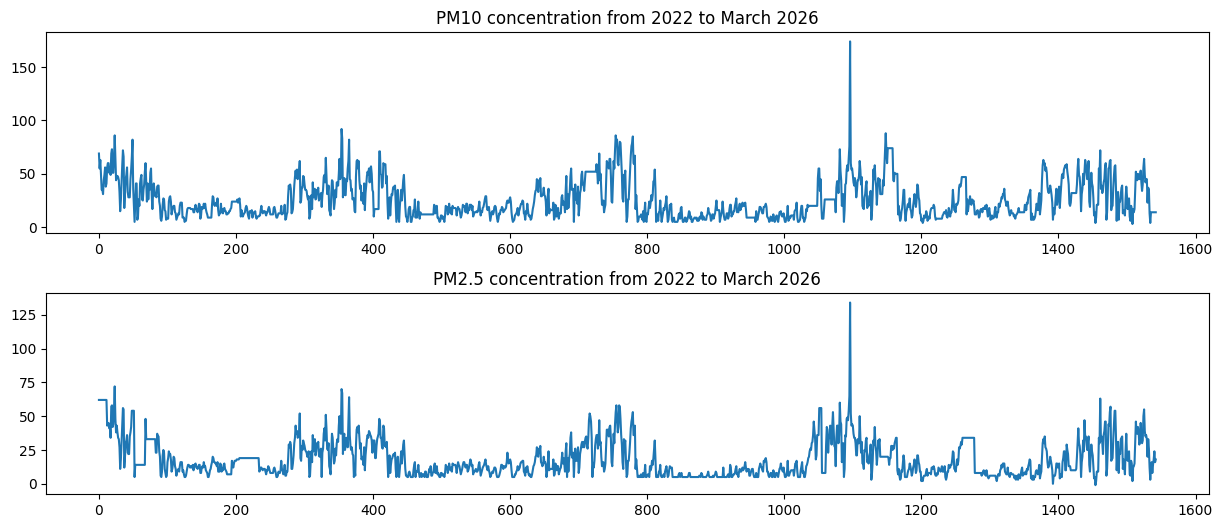

In [16]:
# plotting pm10 and pm2.5

figs, axs = plt.subplots(2,1, figsize = (15,6))
ax = axs[0]
ax.plot(np.arange(1543), data_pm10["Value"].values)
ax.set_title("PM10 concentration from 2022 to March 2026")
figs.subplots_adjust(hspace=0.3)
ax = axs[1]
ax.plot(np.arange(1543), data_pm25["Value"].values)
ax.set_title("PM2.5 concentration from 2022 to March 2026")

plt.show()


In [17]:
# The evolution of both types seem to be very similar
print(np.corrcoef(data_pm10["Value"], data_pm25["Value"]))

[[1.         0.83756139]
 [0.83756139 1.        ]]


We have a strong correlation between PM10 and PM2.5 evolution, this is to be expected since PM2.5 are particles of diamater lower tha 2.5 $\mu m$. We could start by simply predicting the concentration of PM2.5. There also seems to be a seasonal pattern as the concentration seems to increase in the cold season and decrease in the hot period of the year. An outlier point also has to be cleaned from the dataset.

In [18]:
# using the IQR to get rid of outliers
Q3 = data_pm10["Value"].quantile(0.75)
Q1 = data_pm10["Value"].quantile(0.25) 
IQR = Q3 - Q1 # 3rd quartile - 1st quartile

data_pm10["Value"] = data_pm10["Value"].where( # use where to replace outliers by a NaN value
    data_pm10["Value"] <= Q3 + 1.5 * IQR # a value is abnormally high if it is Q3 + 1.5 * IQR
).ffill() # use the same method as previously seen to get rid of outliers

# same for PM 2.5
Q3 = data_pm25["Value"].quantile(0.75)
Q1 = data_pm25["Value"].quantile(0.25) 
IQR = Q3 - Q1 # 3rd quartile - 1st quartile
data_pm25["Valore"] = data_pm25["Value"].where( 
    data_pm25["Value"] <= Q3 + 1.5 * IQR 
).ffill().bfill()

In [19]:
data_pm25.isna().sum()

Date                       0
Time                       0
monitoring_network_id      0
municipality_istat_code    0
municipality_station_id    0
station_name               0
parameter_id               0
parameter_description      0
unit_id                    0
unit_description           0
Value                      0
status                     0
Valore                     0
dtype: int64

In [20]:
# correcting data type of the date
data_pm10["Date"] = pd.to_datetime(data_pm10["Date"], format="%d/%m/%Y")
data_pm25["Date"] = pd.to_datetime(data_pm25["Date"], format="%d/%m/%Y")



#setting up the studied features as a calendar
X = pd.DataFrame({
    "day_of_year": data_pm25["Date"].dt.dayofyear,
    "month":       data_pm25["Date"].dt.month,
    "year":        data_pm25["Date"].dt.year,
})

# adding a lag in order for us to predict based on previous values
X["lag_1"] = data_pm25["Value"].shift(1)   # yesterday
X["lag_7"] = data_pm25["Value"].shift(7)   # same day last week
X["lag_30"] = data_pm25["Value"].shift(30) # same day last month
X["lag_365"] = data_pm25["Value"].shift(365) # same day last year

# addding a weekly and monthly average
X["rolling_7"] = data_pm25["Value"].shift(1).rolling(7).mean() 
X["rolling_30"] = data_pm25["Value"].shift(1).rolling(30).mean()

# since it is a periodic phenomena as observed earlier it is interesting to add a sine and cosine feature
X["sin_day"] = np.sin(2 * np.pi * X["day_of_year"] / 365)
X["cos_day"] = np.cos(2 * np.pi * X["day_of_year"] / 365)

# fill NaNs with moving average
for col in ["lag_1", "lag_7", "lag_30", "rolling_7", "rolling_30"]:
    X[col] = X[col].fillna(data_pm25["Value"].expanding().mean().shift(1))


# for the yearly offset in order not to bias the model with a yearly average it whould be best to fill with a mean on same day of the year basis
day_of_year_mean = data_pm25.groupby(X.day_of_year)["Valore"].mean()
mask = X["lag_365"].isna()
X.loc[mask, "lag_365"] = X.loc[mask, "day_of_year"].map(day_of_year_mean)
display(X.head())

,day_of_year,month,year,lag_1,lag_7,lag_30,lag_365,rolling_7,rolling_30,sin_day,cos_day
0,1,1,2022,NaN,NaN,NaN,42.8,NaN,NaN,0.017213,0.999852
1,2,1,2022,62.0,62.0,62.0,38.4,62.0,62.0,0.034422,0.999407
2,3,1,2022,62.0,62.0,62.0,36.0,62.0,62.0,0.051620,0.998667
3,4,1,2022,62.0,62.0,62.0,32.4,62.0,62.0,0.068802,0.997630
4,5,1,2022,62.0,62.0,62.0,29.6,62.0,62.0,0.085965,0.996298


In [21]:
# filling for first day
expanding_mean = data_pm25["Value"].expanding().mean().shift(1)
day_of_year_mean = data_pm25.groupby(X.day_of_year)["Value"].mean()

# first pass: seasonal fill for lag_365
mask = X["lag_365"].isna()
X.loc[mask, "lag_365"] = X.loc[mask, "day_of_year"].map(day_of_year_mean)

# second pass: expanding mean for all remaining NaNs across all lag columns
for col in ["lag_1", "lag_7", "lag_30", "lag_365", "rolling_7", "rolling_30"]:
    X[col] = X[col].fillna(expanding_mean)

# final fallback: catches the very first rows where expanding mean is also NaN
for col in ["lag_1", "lag_7", "lag_30", "lag_365", "rolling_7", "rolling_30"]:
    X[col] = X[col].fillna(data_pm25["Value"].iloc[0])  # use the first known value

In [22]:
X.isna().sum()

day_of_year    0
month          0
year           0
lag_1          0
lag_7          0
lag_30         0
lag_365        0
rolling_7      0
rolling_30     0
sin_day        0
cos_day        0
dtype: int64

In [23]:
final_dataset = X.copy()
final_dataset["pm2.5 concentration"] = data_pm25["Value"]
final_dataset.to_csv("pollution.csv", index= False)